In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Read the Data

In [2]:
dataframe_QB = pd.read_excel("../final_dataset.xltx", sheet_name="QB")
dataframe_RB = pd.read_excel("../final_dataset.xltx", sheet_name="RB")
dataframe_WR = pd.read_excel("../final_dataset.xltx", sheet_name="WR")

dataframe_QB_carrer_earnings = pd.read_excel("../career_earnings_QB.xltx")
dataframe_RB_carrer_earnings = pd.read_excel("../career_earnings_RB.xltx")
dataframe_WR_carrer_earnings = pd.read_excel("../career_earnings_WR.xltx")

In [3]:
dataframe_QB = dataframe_QB.merge(dataframe_QB_carrer_earnings[['Player', 'Cap-Inflated Earnings']], on="Player", how="left")
dataframe_RB = dataframe_RB.merge(dataframe_RB_carrer_earnings[['Player', 'Cap-Inflated Earnings']], on="Player", how="left")
dataframe_WR = dataframe_WR.merge(dataframe_WR_carrer_earnings[['Player', 'Cap-Inflated Earnings']], on="Player", how="left")

In [4]:
dataframe_WR["Yds"] = dataframe_WR["Yds.1"]
dataframe_RB["Yds"] = dataframe_RB["Yds.1"]
dataframe_QB["Yds"] = dataframe_QB["Yds.1"]

dataframe_RB = dataframe_RB.drop(["Yds.1"], axis=1)
dataframe_WR = dataframe_WR.drop(["Yds.1"], axis=1)
dataframe_QB = dataframe_QB.drop(["Yds.1"], axis=1)

## Transfrom the Data

In [5]:
dataframe_QB['Performance-Index'] = (dataframe_QB['Yds'] /  dataframe_QB['Yds'].max()) * 50 + (dataframe_QB['TD'] /  dataframe_QB['TD'].max()) * 50
dataframe_RB['Performance-Index'] = (dataframe_RB['Yds'] /  dataframe_RB['Yds'].max()) * 50 + (dataframe_RB['TD'] /  dataframe_RB['TD'].max()) * 50
dataframe_WR['Performance-Index'] = (dataframe_WR['Yds'] /  dataframe_WR['Yds'].max()) * 50 + (dataframe_WR['TD'] /  dataframe_WR['TD'].max()) * 50

In [6]:
dataframe_QB

,Player,Yds,Round,Pick,Draft Year,To,G,GS,TD,Seasons in the NFL,Pos,Cap-Inflated Earnings,Performance-Index
0,Tom Brady,89214,6,199,2000,2022,335,333,649,23,QB,"$708,165,480",100.000000
1,Drew Brees,80358,2,32,2001,2020,287,286,571,20,QB,"$606,300,629",89.027408
2,Peyton Manning,71940,1,1,1998,2015,266,265,539,18,QB,"$761,097,143",81.844208
3,Brett Favre,71838,2,33,1991,2010,302,298,508,20,QB,"$580,376,675",79.398752
4,Aaron Rodgers,66274,1,24,2005,2025,264,257,527,21,QB,"$704,306,889",77.744198
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Scott Brunner,6457,6,145,1980,1985,73,30,29,6,QB,NaN,5.853033
246,Hugh Millen,6440,3,71,1986,1995,40,25,22,10,QB,NaN,5.304214
247,Steve Ramsey,6437,5,126,1970,1976,54,31,35,7,QB,NaN,6.304074
248,Jim Miller,6387,6,178,1994,2002,37,27,36,9,QB,NaN,6.353093


In [7]:
dataframe_RB

,Player,Yds,Round,Pick,Draft Year,To,G,GS,TD,Pos,Seasons in the NFL,Cap-Inflated Earnings,Performance-Index
0,Emmitt Smith,18355,1,17,1990,2004,226,219,164,RB,15,"$267,758,332",100.000000
1,Walter Payton,16726,1,4,1975,1987,190,184,110,RB,13,NaN,79.099102
2,Frank Gore,16000,3,65,2005,2020,241,218,81,RB,16,"$147,956,622",68.279976
3,Barry Sanders,15269,1,3,1989,1998,153,151,99,RB,10,"$183,424,034",71.776498
4,Adrian Peterson,14918,1,7,2007,2021,184,167,120,RB,15,"$236,878,277",77.222794
...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,Don Calhoun,3559,10,249,1974,1982,114,50,23,RB,9,NaN,16.707101
247,Kenneth Walker III,3555,2,41,2022,2025,58,54,29,RB,4,"$24,019,497",18.525473
248,Darren Sproles,3552,4,130,2005,2019,183,31,23,RB,15,"$101,311,380",16.688033
249,Tony Nathan,3543,3,61,1979,1987,123,63,16,RB,9,NaN,14.529370


In [8]:
dataframe_WR

,Player,Yds,Round,Pick,Draft Year,To,G,GS,TD,Pos,Seasons in the NFL,Cap-Inflated Earnings,Performance-Index
0,Jerry Rice,22895,1,16,1985,2004,303,284,197,WR,20,"$184,800,205",100.000000
1,Larry Fitzgerald,17492,1,3,2004,2020,263,261,121,WR,17,"$425,891,097",68.911140
2,Terrell Owens,15934,3,89,1996,2010,219,201,153,WR,15,NaN,73.630478
3,Randy Moss,15292,1,21,1998,2012,218,193,156,WR,15,"$288,943,873",72.989847
4,Isaac Bruce,15208,2,33,1994,2009,223,201,91,WR,16,NaN,56.308939
...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,Bill Schroeder,4583,6,181,1994,2004,111,78,28,WR,11,NaN,17.115335
249,Courtney Hawkins,4573,2,44,1992,2000,131,81,18,WR,9,NaN,14.555425
250,Antwaan Randle El,4467,2,62,2002,2010,143,71,15,WR,9,NaN,13.562512
251,Darius Slayton,4435,5,171,2019,2025,106,78,22,WR,7,"$34,076,129",15.269277


## Plot the data

In [9]:
joined_datas = pd.concat([dataframe_QB, dataframe_RB, dataframe_WR])

joined_datas["Cap-Inflated Earnings"] = joined_datas["Cap-Inflated Earnings"].str.replace("$", "", regex=False)\
                           .str.replace(",", "", regex=False)\
                           .astype(float)

In [10]:
joined_datas

,Player,Yds,Round,Pick,Draft Year,To,G,GS,TD,Seasons in the NFL,Pos,Cap-Inflated Earnings,Performance-Index
0,Tom Brady,89214,6,199,2000,2022,335,333,649,23,QB,708165480.0,100.000000
1,Drew Brees,80358,2,32,2001,2020,287,286,571,20,QB,606300629.0,89.027408
2,Peyton Manning,71940,1,1,1998,2015,266,265,539,18,QB,761097143.0,81.844208
3,Brett Favre,71838,2,33,1991,2010,302,298,508,20,QB,580376675.0,79.398752
4,Aaron Rodgers,66274,1,24,2005,2025,264,257,527,21,QB,704306889.0,77.744198
...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,Bill Schroeder,4583,6,181,1994,2004,111,78,28,11,WR,NaN,17.115335
249,Courtney Hawkins,4573,2,44,1992,2000,131,81,18,9,WR,NaN,14.555425
250,Antwaan Randle El,4467,2,62,2002,2010,143,71,15,9,WR,NaN,13.562512
251,Darius Slayton,4435,5,171,2019,2025,106,78,22,7,WR,34076129.0,15.269277


Text(0, 0.5, 'Performance Index')

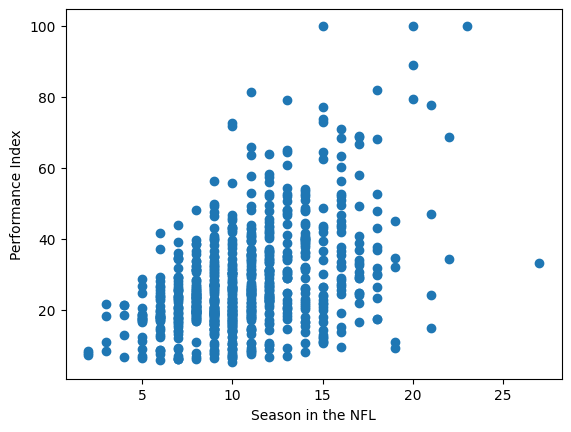

In [12]:
plt.scatter(joined_datas['Seasons in the NFL'], joined_datas['Performance-Index'])
plt.xlabel("Season in the NFL")
plt.ylabel("Performance Index")

Text(0, 0.5, 'Cap-Inflated Earnings')

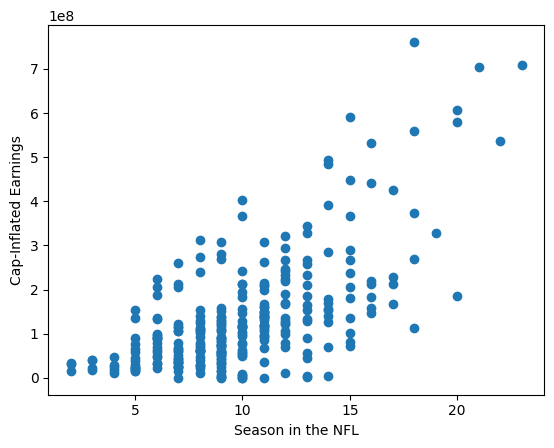

In [13]:
plt.scatter(joined_datas['Seasons in the NFL'], joined_datas['Cap-Inflated Earnings'])
plt.xlabel("Season in the NFL")
plt.ylabel('Cap-Inflated Earnings')